# Bank Customer Classifiaiton 

<center> <b>I N T R O </b> </center>
In today’s competitive financial landscape, understanding customer behavior is more important than ever. Banks and financial institutions gather massive amounts of data from customer transactions, spending patterns, and credit usage. But raw data alone doesn’t provide insights — this is where Artificial Intelligence (AI) steps in.

---
<center> <b>P R O B L E M</b> </center>
  

having massive amounts from transactions data by banking customers and the mass campaigns to all customers is very costly and inefficient when talking about targeting campaigns or making deals and offers with specific merchants

---

<center> <b>O B J E C T I V E</b> </center>


The goal of this use case is to identify distinct segments of credit card users based on their transaction behavior and other key attributes which enables the bank for enhanced targetting campaigns and better deals and offers with merchants based on the bank customer needs which increases customers satisfaction and loyality

The goal of this use case is to identify distinct segments of credit card users based on their transaction behavior and other key attributes. By understanding these segments, banks can tailor marketing strategies, improve customer experience, and optimize credit offerings.

---
<center> <b>D A T A S E T</b> </center>
        

in this project you are required to study the shared data carefully as it's raw data on a transaction level with some details about the customers 

* you are required to generate and build your dataset from your prespective and your understand of the problem 
* generate and add as many features as possible 
* Make sure to validate the values of each column to be logical values of this column
* make the data to be on a customer level which means to make the suitable aggregates to make the customers unique 

---------------------
data set description:
---------------------
1. **TransactionID**: *Unique Transaction ID*  
2. **CustomerID**: *Unique Customer ID*  
3. **CustomerDOB**: *Date of Birth*  
4. **CustGender**: *Gender*  
5. **CustLocation**: *Location*  
6. **CustAccountBalance**: *Account Balance*  
7. **TransactionDate**: *Transaction date*  
8. **TransactionTime**: *Transaction Time (Unix timestamp)*  
9. **TransactionAmount (INR)**: *Amount in INR*  
10. **OwnedProducts**: *Products owned by the customer*  

---
<center> <b>D E L I V E R A B L E S </b> </center>        

* Perform exploratory data analysis (EDA) to understand key variables.

* preprocess the data 

* Apply the suitable unsupervised learning techniques to group customers based on the customers features 

* Interpret the resulting segments and suggest possible actions a bank could take for each group.

Skills You'll Practice:

    * data set creation and data wrangling techniques

    * Data cleaning and preprocessing

    * Feature selection and scaling

    * Clustering algorithms 

    * Visualization and interpretation of resulted clusters



**********************
  Notes : 
**********************

the final delivery will be in a :

* jupyter notebook contains all project steps 

* well organized code and documentation (short description for the purpose of each step)

* trials log contains all your modelling trials until you reach to a satisfying results (contains details about the model used and the hyper parpameter values and the evaluation of each trial)

---
<center> <b>BONUS  SECTION</b> </center>

Try to build a recommendation system that recommends bank products or investment plans based on the customer segmentation features and clustering results (You can use clustering for product recommendations by identifying products owned by some customers within a cluster and suggesting those products to other customers in the same cluster who don’t have them yet )

<center> <b>THANK YOU AND GOOD LUCK</b> </center>

## Data Preparation 

### Reading Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
raw = pd.read_csv('data/bank_customer_transactions.csv')

ParserError: Error tokenizing data. C error: Expected 12 fields in line 9, saw 13


Looks like there is a problem with the number of columns, looking at the csv file I see that the last column should contain more than value but it's listed as values seperated by commas.

to solve this there are more than one approach:
1.  Define my own function to read the csv then feed it into a dataframe
2.  Read the file normally as text and change all the commas after the 9th one.
3.  Read all the data into one column then split it manually.

Let's try the third method.


In [3]:
raw = pd.read_csv('data/bank_customer_transactions.csv',header=0, delimiter='just random text')
raw.head()

/tmp/ipykernel_26966/3624967539.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw = pd.read_csv('data/bank_customer_transactions.csv',header=0, delimiter='just random text')


,"TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),OwnedProducts"
0,"T1,C5841053,1994+AC0-01+AC0-10,F,JAMSHEDPUR,17..."
1,"T2,C2142763,2057+AC0-04+AC0-04,M,JHAJJAR,2270...."
2,"T3,C4417068,1996+AC0-11+AC0-26,F,MUMBAI,17874...."
3,"T4,C5342380,2073+AC0-09+AC0-14,F,MUMBAI,866503..."
4,"T5,C9031234,1988+AC0-03+AC0-24,F,NAVI MUMBAI,6..."


In [4]:
raw[['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender', 'CustLocation', 'CustAccountBalance', 'TransactionDate', 'TransactionTime', 'TransactionAmount', 'OwnedProducts']] = raw.iloc[:,0].str.split(',', expand=True, n=9)

In [5]:
first_column = raw.columns[0]
raw = raw.drop(first_column, axis=1)
raw.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount,OwnedProducts
0,T1,C5841053,1994+AC0-01+AC0-10,F,JAMSHEDPUR,17819.05,2/8/16,143207,25,"+ACI-credit card, loans, savings+ACI-"
1,T2,C2142763,2057+AC0-04+AC0-04,M,JHAJJAR,2270.69,2/8/16,141858,27999,tds
2,T3,C4417068,1996+AC0-11+AC0-26,F,MUMBAI,17874.44,2/8/16,142712,459,"+ACI-loans, savings+ACI-"
3,T4,C5342380,2073+AC0-09+AC0-14,F,MUMBAI,866503.21,2/8/16,142714,2060,"+ACI-long term investment, savings+ACI-"
4,T5,C9031234,1988+AC0-03+AC0-24,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5,"+ACI-loans, savings+ACI-"


In [6]:
raw.shape

(1048567, 10)

In [7]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype 
---  ------              --------------    ----- 
 0   TransactionID       1048567 non-null  object
 1   CustomerID          1048567 non-null  object
 2   CustomerDOB         1048567 non-null  object
 3   CustGender          1048567 non-null  object
 4   CustLocation        1048567 non-null  object
 5   CustAccountBalance  1048567 non-null  object
 6   TransactionDate     1048567 non-null  object
 7   TransactionTime     1048567 non-null  object
 8   TransactionAmount   1048567 non-null  object
 9   OwnedProducts       1048567 non-null  object
dtypes: object(10)
memory usage: 80.0+ MB


### Cleaning Data

#### cutomerDOB

In [8]:
raw['CustomerDOB'] = raw['CustomerDOB'].str.replace('+AC0-','-')
raw['CustomerDOB'] = pd.to_datetime(raw['CustomerDOB'])
raw['CustomerDOB']

0         1994-01-10
1         2057-04-04
2         1996-11-26
3         2073-09-14
4         1988-03-24
             ...    
1048562   1990-04-08
1048563   1992-02-20
1048564   1989-05-18
1048565   1978-08-30
1048566   1984-03-05
Name: CustomerDOB, Length: 1048567, dtype: datetime64[ns]

In [9]:
raw.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount,OwnedProducts
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2/8/16,143207,25,"+ACI-credit card, loans, savings+ACI-"
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2/8/16,141858,27999,tds
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2/8/16,142712,459,"+ACI-loans, savings+ACI-"
3,T4,C5342380,2073-09-14,F,MUMBAI,866503.21,2/8/16,142714,2060,"+ACI-long term investment, savings+ACI-"
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5,"+ACI-loans, savings+ACI-"


In [10]:
years = raw['CustomerDOB'].dt.year

In [11]:
year_counts = years.value_counts().sort_index()
year_counts

CustomerDOB
1800.0    57339
1975.0    12332
1976.0    15109
1977.0    16650
1978.0    19658
          ...  
2070.0     7283
2071.0     7420
2072.0     9221
2073.0     9957
2074.0    10973
Name: count, Length: 100, dtype: int64

That's interesting. looks like there are a lot of wrong values here, unless the bank has a branch for the dead and another for time travellers.

In [12]:
year_counts_filtered = years[(years<1975) | (years >2015)]
year_counts_filtered.value_counts().sort_index()

CustomerDOB
1800.0    57339
2016.0        2
2018.0        1
2019.0        7
2020.0        2
2021.0       22
2022.0        3
2023.0        6
2024.0        3
2025.0        1
2026.0       10
2027.0       49
2028.0       22
2029.0       63
2030.0       63
2031.0       73
2032.0       79
2033.0       73
2034.0       67
2035.0       97
2036.0      108
2037.0      164
2038.0      245
2039.0      183
2040.0      293
2041.0      290
2042.0      400
2043.0      303
2044.0      412
2045.0      395
2046.0      463
2047.0      708
2048.0      726
2049.0      794
2050.0     1124
2051.0     1039
2052.0     1480
2053.0     1499
2054.0     1801
2055.0     1768
2056.0     1555
2057.0     1586
2058.0     1615
2059.0     2142
2060.0     2233
2061.0     2179
2062.0     3029
2063.0     3212
2064.0     3582
2065.0     3894
2066.0     4202
2067.0     4459
2068.0     5903
2069.0     5965
2070.0     7283
2071.0     7420
2072.0     9221
2073.0     9957
2074.0    10973
Name: count, dtype: int64

In [13]:
year_counts_filtered.value_counts().sum()/raw.shape[0]

0.15505637694110153

Well, dropping all the rows with wrong DOB will result in dropping 15% of the transactions.
instead of dropping them I'll exclude them into a seprate dataframe to see if there is a relation between them.

In [14]:
weird_ages = raw.iloc[year_counts_filtered.index].copy()
processed_raw = raw.drop(year_counts_filtered.index, axis=0)

In [15]:
processed_raw['CustomerDOB'].dt.year.describe()

count    882583.000000
mean       1987.291585
std           5.169653
min        1975.000000
25%        1984.000000
50%        1988.000000
75%        1991.000000
max        2015.000000
Name: CustomerDOB, dtype: float64

In [16]:
processed_raw['CustomerDOB'].isna().sum()

3397

In [17]:
processed_raw = processed_raw.dropna(subset=['CustomerDOB'])

Success !!


#### Customer Gender

In [18]:
processed_raw['CustGender'].unique()

array(['F', 'M', ''], dtype=object)

In [19]:
processed_raw['CustGender'].value_counts()

CustGender
M    637788
F    244782
         13
Name: count, dtype: int64

Let's just also move them into a seperate group.
Notice that this is a dataframe where we filtered the bad data of birth rows. so we need to extract the info about the missing gender from the main dataframe


In [20]:
weird_gender = raw[raw['CustGender']=='']
weird_gender['CustomerDOB'].dt.year.value_counts()

CustomerDOB
1800.0    873
2050.0    151
2005.0     13
Name: count, dtype: int64

In [21]:
weird_gender[weird_gender['CustomerDOB'].dt.year == 2005]

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount,OwnedProducts
67902,T67903,C3316138,2005-04-29,,MUMBAI,44590.44,2/8/16,131845,289.92,savings
87894,T87895,C5716187,2005-04-29,,MUMBAI,44590.44,1/8/16,171229,434.88,savings
100657,T100658,C8916146,2005-04-29,,MUMBAI,44590.44,1/8/16,185412,836.3,"+ACI-long term investment, savings+ACI-"
122524,T122525,C1116141,2005-04-29,,MUMBAI,44590.44,6/8/16,171503,981.2,savings
124629,T124630,C1416155,2005-04-29,,MUMBAI,44590.44,6/8/16,171618,981.2,savings
142108,T142109,C6316117,2005-04-29,,MUMBAI,44590.44,5/8/16,130023,1338,savings
143047,T143048,C7216161,2005-04-29,,MUMBAI,44590.44,5/8/16,190542,1471.8,savings
163425,T163426,C8916185,2005-04-29,,MUMBAI,44590.44,4/8/16,134848,44563,savings
163787,T163788,C5816160,2005-04-29,,MUMBAI,44590.44,4/8/16,181654,401.4,"+ACI-loans, savings+ACI-"
169775,T169776,C2916112,2005-04-29,,MUMBAI,44590.44,4/8/16,182349,401.4,savings


Interesting, all the transactions with the same error happened from customers with the same date of birth, yet they are different customers with different IDs, also same location. I think it maybe a data entry error. so let's just drop these rows.

In [22]:
gender_indexes = processed_raw[processed_raw['CustGender'] == '']
processed_raw = processed_raw.drop(gender_indexes.index, axis=0)

In [23]:
processed_raw.CustGender.value_counts()

CustGender
M    637788
F    244782
Name: count, dtype: int64

In [24]:
gender_check = processed_raw.groupby('CustomerID')['CustGender'].nunique()
gender_check[gender_check == 2].sum()

89442

That's interesting, some customers changed gender between transactions 😅!!

We can try to solve that by updating the genders and use the most frequent gender for a customer since the odd gender mostly is a data entry issue.

In [25]:
cust_gender_mode = processed_raw.groupby('CustomerID')['CustGender'].agg(lambda x:x.mode()[0])
processed_raw['CustGender'] = processed_raw['CustomerID'].map(cust_gender_mode)
processed_raw

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount,OwnedProducts
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2/8/16,143207,25,"+ACI-credit card, loans, savings+ACI-"
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2/8/16,142712,459,"+ACI-loans, savings+ACI-"
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5,"+ACI-loans, savings+ACI-"
6,T7,C7126560,1992-01-26,M,MUMBAI,973.46,2/8/16,173806,566,"+ACI-loans, retirement plan+ACI-"
7,T8,C1220223,1982-01-27,M,MUMBAI,95075.54,2/8/16,170537,148,"+ACI-cds, credit card, retirement plan, saving..."
...,...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,1990-04-08,M,NEW DELHI,7635.19,18/9/16,184824,799,"+ACI-loans, savings+ACI-"
1048563,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,18/9/16,183734,460,"+ACI-credit card, loans, savings+ACI-"
1048564,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,18/9/16,183313,770,"+ACI-cds, credit card, retirement plan, saving..."
1048565,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,18/9/16,184706,1000,"+ACI-credit card, loans, savings+ACI-"


In [26]:
gender_check = processed_raw.groupby('CustomerID')['CustGender'].nunique()
gender_check[gender_check == 2].sum()

0

Success !!

#### Customer Account Balance

In [27]:
processed_raw['CustAccountBalance'].describe()

count     882570
unique    133125
top             
freq        1973
Name: CustAccountBalance, dtype: object

Hmm, seems like the non existant values are paresed as empty strings

In [28]:
processed_raw[processed_raw['CustAccountBalance'] == '']['TransactionDate'].unique()

array(['3/8/16', '21/10/16', '22/9/16', '16/8/16', '25/9/16', '27/9/16',
       '26/9/16', '23/9/16', '30/9/16', '2/8/16', '1/8/16', '6/8/16',
       '5/8/16', '4/8/16', '3/9/16', '9/8/16', '8/8/16', '7/8/16',
       '12/8/16', '11/8/16', '10/8/16', '15/8/16', '14/8/16', '13/8/16',
       '18/8/16', '17/8/16', '21/8/16', '20/8/16', '19/8/16', '24/8/16',
       '23/8/16', '22/8/16', '27/8/16', '25/8/16', '26/8/16', '28/8/16',
       '29/8/16', '31/8/16', '30/8/16', '2/9/16', '1/9/16', '6/9/16',
       '5/9/16', '4/9/16', '9/9/16', '8/9/16', '7/9/16', '12/9/16',
       '11/9/16', '10/9/16', '15/9/16', '14/9/16', '13/9/16', '18/9/16'],
      dtype=object)

In [29]:
1827/841583

0.002170908870545151

I don't know what happened in 2016 but all the empty Account balances share this year!! It's worth invistigating in the data entry level. what happened in that year in the months August and September.

Anyways, Since we have large dataset I'll just drop those rows, they are just around $0.2%$ of the data. And since they're probably just data entry error in those two months. we can safely drop them without any concern of missing valuabe info.

In [30]:
missing_balance = processed_raw[processed_raw['CustAccountBalance'] == '']
processed_raw = processed_raw.drop(missing_balance.index,  axis=0)

Let's check wether there is non-numeric values.

In [31]:
processed_raw[~pd.to_numeric(processed_raw['CustAccountBalance'], errors='coerce').notna()]['CustAccountBalance'].unique()

array(['THANE+ACI-', 'BANGALORE+ACI-', ' ASSAM+ACI-', ' NAGALAND+ACI-',
       ' MIZORAM+ACI-', ' BANGALORE+ACI-', 'MADHYA PRADESH+ACI-',
       'AP+ACI-', 'MUMBAI+ACI-', ' MUMBAI+ACI-', ' HARCHANDPUR+ACI-',
       ' PUNE+ACI-', 'PUNE+ACI-', 'NALGONDA(DIST)+ACI-', 'WARANGAL+ACI-'],
      dtype=object)

In [32]:
states = processed_raw[~pd.to_numeric(processed_raw['CustAccountBalance'], errors='coerce').notna()]['CustAccountBalance'].unique()

In [33]:
processed_raw[~pd.to_numeric(processed_raw['CustAccountBalance'], errors='coerce').notna()]['CustAccountBalance'].count()

411

Those apparently are just rows that got misshifted columns

In [34]:
weird_balance = processed_raw[processed_raw['CustAccountBalance'].isin(states)]
weird_balance

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount,OwnedProducts
742,T743,C6611233,1986-09-14,M,+ACI-DOMBIVALI +AC0-WEST,THANE+ACI-,4149.06,21/10/16,215115,"700,loans"
3257,T3258,C6430823,1987-04-17,F,+ACI-WHITEFIELD,BANGALORE+ACI-,1253.32,21/10/16,163240,"1400.12,loans"
5322,T5323,C1842711,1988-12-31,M,+ACI-JORHAT,ASSAM+ACI-,39042.52,16/8/16,94642,"50,+ACI-credit card, savings+ACI-"
6021,T6022,C7531487,1995-03-19,F,+ACI-DIMAPUR,NAGALAND+ACI-,273989.77,25/9/16,212119,"20,+ACI-cds, credit card, long term investment..."
6415,T6416,C1299617,1990-12-26,M,+ACI-AIZAWL,MIZORAM+ACI-,1224.91,27/9/16,183352,"150,loans"
...,...,...,...,...,...,...,...,...,...,...
1022089,T1022090,C6821958,1985-05-21,M,+ACI-AIZAWL,MIZORAM+ACI-,19839.47,13/9/16,73211,"130,+ACI-credit card, loans, savings+ACI-"
1028162,T1028163,C5817963,1982-01-01,F,+ACI-.+AC0-PURAM,BANGALORE+ACI-,12975.55,13/9/16,173334,"250,+ACI-credit card, loans, savings+ACI-"
1037523,T1037524,C1828838,1992-01-02,M,+ACI-DIMAPUR,NAGALAND+ACI-,91.56,18/9/16,151335,"522.59,loans"
1045258,T1045259,C4842671,1979-03-25,M,+ACI-.+AC0-PURAM,BANGALORE+ACI-,88087.06,18/9/16,115836,"100,+ACI-cds, credit card, retirement plan, sa..."


Searching online I realized that Assam and Nagaland are actually state names, so I'll use those values inplace of the current values in CustLocation and then shift all other values one column to the left.

In [35]:
weird_balance = weird_balance.loc[:,  'CustLocation':].shift(-1, axis=1)
weird_balance

,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount,OwnedProducts
742,THANE+ACI-,4149.06,21/10/16,215115,"700,loans",None
3257,BANGALORE+ACI-,1253.32,21/10/16,163240,"1400.12,loans",None
5322,ASSAM+ACI-,39042.52,16/8/16,94642,"50,+ACI-credit card, savings+ACI-",None
6021,NAGALAND+ACI-,273989.77,25/9/16,212119,"20,+ACI-cds, credit card, long term investment...",None
6415,MIZORAM+ACI-,1224.91,27/9/16,183352,"150,loans",None
...,...,...,...,...,...,...
1022089,MIZORAM+ACI-,19839.47,13/9/16,73211,"130,+ACI-credit card, loans, savings+ACI-",None
1028162,BANGALORE+ACI-,12975.55,13/9/16,173334,"250,+ACI-credit card, loans, savings+ACI-",None
1037523,NAGALAND+ACI-,91.56,18/9/16,151335,"522.59,loans",None
1045258,BANGALORE+ACI-,88087.06,18/9/16,115836,"100,+ACI-cds, credit card, retirement plan, sa...",None


In [36]:
weird_balance['TransactionAmount'].str.split(',', n=1, expand=True)

,0,1
742,700,loans
3257,1400.12,loans
5322,50,"+ACI-credit card, savings+ACI-"
6021,20,"+ACI-cds, credit card, long term investment, s..."
6415,150,loans
...,...,...
1022089,130,"+ACI-credit card, loans, savings+ACI-"
1028162,250,"+ACI-credit card, loans, savings+ACI-"
1037523,522.59,loans
1045258,100,"+ACI-cds, credit card, retirement plan, saving..."


In [37]:
weird_balance

,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount,OwnedProducts
742,THANE+ACI-,4149.06,21/10/16,215115,"700,loans",None
3257,BANGALORE+ACI-,1253.32,21/10/16,163240,"1400.12,loans",None
5322,ASSAM+ACI-,39042.52,16/8/16,94642,"50,+ACI-credit card, savings+ACI-",None
6021,NAGALAND+ACI-,273989.77,25/9/16,212119,"20,+ACI-cds, credit card, long term investment...",None
6415,MIZORAM+ACI-,1224.91,27/9/16,183352,"150,loans",None
...,...,...,...,...,...,...
1022089,MIZORAM+ACI-,19839.47,13/9/16,73211,"130,+ACI-credit card, loans, savings+ACI-",None
1028162,BANGALORE+ACI-,12975.55,13/9/16,173334,"250,+ACI-credit card, loans, savings+ACI-",None
1037523,NAGALAND+ACI-,91.56,18/9/16,151335,"522.59,loans",None
1045258,BANGALORE+ACI-,88087.06,18/9/16,115836,"100,+ACI-cds, credit card, retirement plan, sa...",None


In [38]:
# Data Cleaning

weird_balance[['TransactionAmount', 'OwnedProducts']] = weird_balance['TransactionAmount'].str.split(',', n=1, expand=True)
weird_balance['CustLocation'] = weird_balance['CustLocation'].str.replace('+ACI-', '')
weird_balance

,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount,OwnedProducts
742,THANE,4149.06,21/10/16,215115,700,loans
3257,BANGALORE,1253.32,21/10/16,163240,1400.12,loans
5322,ASSAM,39042.52,16/8/16,94642,50,"+ACI-credit card, savings+ACI-"
6021,NAGALAND,273989.77,25/9/16,212119,20,"+ACI-cds, credit card, long term investment, s..."
6415,MIZORAM,1224.91,27/9/16,183352,150,loans
...,...,...,...,...,...,...
1022089,MIZORAM,19839.47,13/9/16,73211,130,"+ACI-credit card, loans, savings+ACI-"
1028162,BANGALORE,12975.55,13/9/16,173334,250,"+ACI-credit card, loans, savings+ACI-"
1037523,NAGALAND,91.56,18/9/16,151335,522.59,loans
1045258,BANGALORE,88087.06,18/9/16,115836,100,"+ACI-cds, credit card, retirement plan, saving..."


In [39]:
processed_raw.update(weird_balance)

In [40]:
processed_raw[~pd.to_numeric(processed_raw['CustAccountBalance'], errors='coerce').notna()]['CustAccountBalance'].unique()

array([], dtype=object)

In [41]:
processed_raw['CustAccountBalance'] = pd.to_numeric(processed_raw['CustAccountBalance'])
processed_raw

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount,OwnedProducts
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2/8/16,143207,25,"+ACI-credit card, loans, savings+ACI-"
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2/8/16,142712,459,"+ACI-loans, savings+ACI-"
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5,"+ACI-loans, savings+ACI-"
6,T7,C7126560,1992-01-26,M,MUMBAI,973.46,2/8/16,173806,566,"+ACI-loans, retirement plan+ACI-"
7,T8,C1220223,1982-01-27,M,MUMBAI,95075.54,2/8/16,170537,148,"+ACI-cds, credit card, retirement plan, saving..."
...,...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,1990-04-08,M,NEW DELHI,7635.19,18/9/16,184824,799,"+ACI-loans, savings+ACI-"
1048563,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,18/9/16,183734,460,"+ACI-credit card, loans, savings+ACI-"
1048564,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,18/9/16,183313,770,"+ACI-cds, credit card, retirement plan, saving..."
1048565,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,18/9/16,184706,1000,"+ACI-credit card, loans, savings+ACI-"


Success !!

#### Customer location

In [42]:
processed_raw['CustLocation'].value_counts()

CustLocation
MUMBAI                               86350
BANGALORE                            70769
NEW DELHI                            66256
GURGAON                              62812
DELHI                                60574
                                     ...  
COMPLEX MUMBAI                           1
ANDHERI (WEST)  MUMBAI                   1
LAYOUT 5TH PHASE JP NGR BANGALORE        1
SANYUKTA NAGAR NALLASOPARA EAST          1
IMPERIA THANE WEST                       1
Name: count, Length: 7482, dtype: int64

In [43]:
processed_raw['CustLocation'].value_counts()[800:].sum() # 800 is the number of districts in India

54988

In [44]:
processed_raw['CustLocation'] = processed_raw['CustLocation'].str.replace('+AC0-', '')
processed_raw['CustLocation'] = processed_raw['CustLocation'].str.replace('+ACI-', '')

Oh, that's huge number of locations?! what is that?! states?  districts? street names?! I don't know to be honest. but in dataset of 1M rows, if a location has repeated only a handful of times, it's probably just a data entry error, or very niche location that won't real provide any value. 

Let's try to merge alike locations

In [45]:
from rapidfuzz import process, fuzz

In [46]:
locations = processed_raw['CustLocation'].str.strip().str.upper()
unique_locations = locations.unique()
location_mapping ={}
already_mapped = set()

for loc in unique_locations:
    if loc in already_mapped:
        continue
    
    matches =process.extract(loc, unique_locations, scorer=fuzz.token_sort_ratio)
    for match, score,  _  in  matches:
        if match == loc:  # skip mapping a value to itself
            continue
        
        if score >= 85:
            location_mapping[match] =loc
            already_mapped.add(match)

location_mapping

{'JAMSAEDPUR': 'JAMSHEDPUR',
 'DMUMBAI': 'MUMBAI',
 'MUMAI': 'MUMA',
 'W MUMBAI': 'NEW MUMBAI',
 'E MUMBAI': 'MUMBAI E',
 'NAVI  MUMBAI': 'NAVI MUMABI',
 'NAVI MUMAI': 'NAVI MUMABI',
 'NAVI MUMBI': 'NAVI MUMABI',
 '3 NAVI MUMBAI': 'NAVI MUMBAI',
 'GURGAOPN': 'GURGAON',
 'GURAGAON': 'GURGAON',
 'GURGGAON': 'GURGAON',
 'GUGAON': 'GUDGAON',
 'AHMEDBAD': 'AHMEDABAD',
 'AHEMDABAD': 'AHMEDABAD',
 'AHMADABAD': 'AHMEDABAD',
 'RD AHMEDABAD': 'ROAD AHMEDABAD',
 'THANEW': 'THANE W',
 'B NO 3 KALYANI NAGAR PUNE': 'NO 3 KALYANI NAGAR PUNE',
 '3 KALYANI NAGAR PUNE': 'NO 3 KALYANI NAGAR PUNE',
 'KALYANI NAGAR PUNE': 'NO 3 KALYANI NAGAR PUNE',
 'KAYANI NAGAR PUNE': 'NO 3 KALYANI NAGAR PUNE',
 'SECUDERABAD': 'SECUNDERABAD',
 'NGR SECUNDERABAD': 'SECUNDERABAD',
 'LACKNOW': 'LUCKNOW',
 'LUCKNOE': 'LUCKNOW',
 'CHEENAI': 'CHENNAI',
 'CHANNAI': 'CHENNAI',
 'GHAZIZABAD': 'GHAZIABAD',
 'GAZIABAD': 'GHAZIABAD',
 'GHAZAIBAD': 'GHAZIABAD',
 'GHAIZABAD': 'GHAZIABAD',
 'BANAGALORE': 'BANAGLORE',
 'BANGLORE': 'BANG

In [47]:
processed_raw['CustLocation'] = processed_raw['CustLocation'].replace(location_mapping)

In [48]:
processed_raw['CustLocation'].value_counts()

CustLocation
MUMBAI E                     86421
BANGLAORE                    70865
T3 NEW DELHI                 66297
GUDGAON                      62815
DELHI                        60574
                             ...  
NXT TO APNA BAZAAR MUMBAI        1
BELLANDUR BANGALORE              1
RAJKOT HIGHWAY AHMEDABAD         1
TALEIGAO PANAJI                  1
IMPERIA THANE WEST               1
Name: count, Length: 5873, dtype: int64

Let's check if each user does transactions over one or more locations.

In [49]:
location_check = processed_raw.groupby('CustomerID')['CustLocation'].nunique()
location_check.sort_values()

CustomerID
C5031292    1
C6215121    1
C6215122    1
C6215126    1
C6215128    1
           ..
C4638126    5
C4725431    5
C6735477    6
C1026833    6
C6222360    6
Name: CustLocation, Length: 762034, dtype: int64

hmm, Apparently the same user can do transactions from more than one location.

For now let's just combine the tail of the location data into others, that is, apply filtering by cumulative coverage.

In [50]:
location_counts = processed_raw['CustLocation'].value_counts()
cumulative_percentage = location_counts.cumsum() / location_counts.sum()
cumulative_percentage

CustLocation
MUMBAI E                     0.098139
BANGLAORE                    0.178613
T3 NEW DELHI                 0.253899
GUDGAON                      0.325232
DELHI                        0.394019
                               ...   
NXT TO APNA BAZAAR MUMBAI    0.999995
BELLANDUR BANGALORE          0.999997
RAJKOT HIGHWAY AHMEDABAD     0.999998
TALEIGAO PANAJI              0.999999
IMPERIA THANE WEST           1.000000
Name: count, Length: 5873, dtype: float64

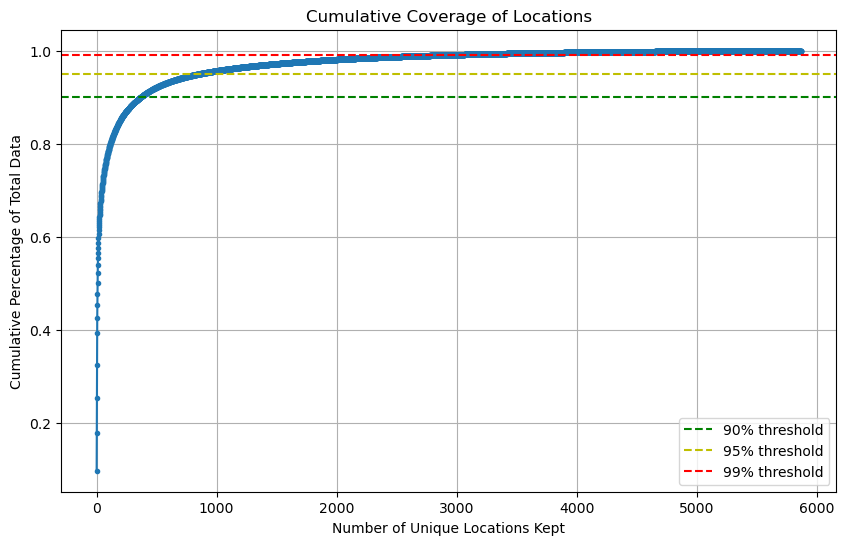

In [51]:
plt.figure(figsize=(10,6))
plt.plot(range(len(cumulative_percentage)), cumulative_percentage, marker='.')
plt.xlabel('Number of Unique Locations Kept')
plt.ylabel('Cumulative Percentage of Total Data')
plt.title('Cumulative Coverage of Locations')
plt.grid(True)
plt.axhline(0.90, color='g', linestyle='--', label='90% threshold')
plt.axhline(0.95, color='y', linestyle='--', label='95% threshold')
plt.axhline(0.99, color='r', linestyle='--', label='99% threshold')
plt.legend()
plt.show()

I think 95 is a just fit to not lose too much data

In [52]:
locations_to_keep = cumulative_percentage[cumulative_percentage <= 0.95].index
processed_raw[processed_raw['CustLocation'].isin(locations_to_keep)]['CustLocation'].value_counts()

CustLocation
MUMBAI E            86421
BANGLAORE           70865
T3 NEW DELHI        66297
GUDGAON             62815
DELHI               60574
                    ...  
CHIPLUN                46
GOBINDGARH             46
SCHOOL CHENNAI         46
BANGALROE              46
EXPRESSWAY NOIDA       46
Name: count, Length: 852, dtype: int64

In [53]:
processed_raw['CustLocation'] = processed_raw['CustLocation'].apply(lambda x: x if x in locations_to_keep else 'Others' )

In [54]:
processed_raw['CustLocation'].value_counts()['Others']

44052

Success!!

#### Transaction Date

In [55]:
processed_raw.TransactionDate.describe()

count     880597
unique        55
top       7/8/16
freq       23350
Name: TransactionDate, dtype: object

In [56]:
processed_raw.TransactionDate.unique()

array(['2/8/16', '1/8/16', '3/8/16', '5/8/16', '4/8/16', '6/8/16',
       '9/8/16', '8/8/16', '12/8/16', '7/8/16', '21/10/16', '16/10/16',
       '10/8/16', '14/8/16', '17/8/16', '21/8/16', '19/8/16', '24/8/16',
       '22/8/16', '29/8/16', '22/9/16', '23/9/16', '13/8/16', '25/8/16',
       '28/8/16', '15/8/16', '27/8/16', '31/8/16', '20/8/16', '23/8/16',
       '30/8/16', '11/8/16', '16/8/16', '26/8/16', '27/9/16', '18/8/16',
       '25/9/16', '26/9/16', '30/9/16', '3/9/16', '2/9/16', '1/9/16',
       '6/9/16', '5/9/16', '4/9/16', '9/9/16', '8/9/16', '7/9/16',
       '12/9/16', '11/9/16', '10/9/16', '15/9/16', '14/9/16', '13/9/16',
       '18/9/16'], dtype=object)

In [57]:
processed_raw['TransactionDate'] = pd.to_datetime(processed_raw.TransactionDate, format='%d/%m/%y')

Huh, Interesting. No problems while parsing the column to datatime.

It also makes sense now why all the empty account balance column was on August and September, As all of our data is in August or September of 2016. that also makes us further clean the Data of Birth column, since no one of age less than 10 years can do any type of transaction. Minors of age 10 can do limited transactions, therefore all people of birth date less than 2006 are supposed to be wrong entry data.

#### Revisiting Date of Birth

In [58]:
processed_raw['CustomerDOB'].dt.year.unique()

array([1994, 1996, 1988, 1992, 1982, 1984, 1978, 1989, 1991, 1985, 1993,
       1986, 1979, 1977, 1997, 1983, 1990, 1980, 1981, 1987, 1975, 1995,
       1999, 1976, 2004, 1998, 2000, 2002, 2007, 2001, 2013, 2003, 2005,
       2010, 2011, 2009, 2015, 2006, 2008, 2012, 2014], dtype=int32)

In [59]:
processed_raw = processed_raw[processed_raw['CustomerDOB'].dt.year<2006]
processed_raw['CustomerDOB'].dt.year.unique()

array([1994, 1996, 1988, 1992, 1982, 1984, 1978, 1989, 1991, 1985, 1993,
       1986, 1979, 1977, 1997, 1983, 1990, 1980, 1981, 1987, 1975, 1995,
       1999, 1976, 2004, 1998, 2000, 2002, 2001, 2003, 2005], dtype=int32)

Success !!

In [60]:
processed_raw

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount,OwnedProducts
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,143207,25,"+ACI-credit card, loans, savings+ACI-"
2,T3,C4417068,1996-11-26,F,MUMBAI E,17874.44,2016-08-02,142712,459,"+ACI-loans, savings+ACI-"
4,T5,C9031234,1988-03-24,F,NAVI MUMABI,6714.43,2016-08-02,181156,1762.5,"+ACI-loans, savings+ACI-"
6,T7,C7126560,1992-01-26,M,MUMBAI E,973.46,2016-08-02,173806,566,"+ACI-loans, retirement plan+ACI-"
7,T8,C1220223,1982-01-27,M,MUMBAI E,95075.54,2016-08-02,170537,148,"+ACI-cds, credit card, retirement plan, saving..."
...,...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,1990-04-08,M,T3 NEW DELHI,7635.19,2016-09-18,184824,799,"+ACI-loans, savings+ACI-"
1048563,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,2016-09-18,183734,460,"+ACI-credit card, loans, savings+ACI-"
1048564,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,2016-09-18,183313,770,"+ACI-cds, credit card, retirement plan, saving..."
1048565,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,2016-09-18,184706,1000,"+ACI-credit card, loans, savings+ACI-"


#### Transaction Time

It's said that this is supposed to be unix timestamp

In [61]:
processed_raw.TransactionTime

0          143207
2          142712
4          181156
6          173806
7          170537
            ...  
1048562    184824
1048563    183734
1048564    183313
1048565    184706
1048566    181222
Name: TransactionTime, Length: 880391, dtype: object

In [62]:
processed_raw.TransactionTime.isna().sum()

0

In [63]:
processed_raw.TransactionTime.astype(float).max(), processed_raw.TransactionTime.astype(float).min()

(235959.0, 0.0)

This looks more like time of day more than a unix timestamp. so time of day in the form `HHMMSS`, hence the min is 0 and max is 235959. we can actually combine that with the previous transaction date to have a complete datetime column.

In [64]:
processed_raw['TransactionTime']

0          143207
2          142712
4          181156
6          173806
7          170537
            ...  
1048562    184824
1048563    183734
1048564    183313
1048565    184706
1048566    181222
Name: TransactionTime, Length: 880391, dtype: object

In [65]:
processed_raw['TransactionTime'] = pd.to_datetime(processed_raw['TransactionTime'].str.zfill(6), format = '%H%M%S').dt.time

/tmp/ipykernel_26966/1138043060.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_raw['TransactionTime'] = pd.to_datetime(processed_raw['TransactionTime'].str.zfill(6), format = '%H%M%S').dt.time


In [66]:
processed_raw['TransactionDate'] = pd.to_datetime(processed_raw['TransactionDate']).dt.date

processed_raw['TransactionDateTime'] = processed_raw.apply(
    lambda row: pd.Timestamp.combine(row['TransactionDate'], row['TransactionTime']),
    axis=1
)

/tmp/ipykernel_26966/4120786403.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_raw['TransactionDate'] = pd.to_datetime(processed_raw['TransactionDate']).dt.date
/tmp/ipykernel_26966/4120786403.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_raw['TransactionDateTime'] = processed_raw.apply(


Droping Date and Time columns since they are redundunt now.

In [67]:

processed_raw = processed_raw.drop(['TransactionDate', 'TransactionTime'], axis=1)

In [68]:
processed_raw

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionAmount,OwnedProducts,TransactionDateTime
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,25,"+ACI-credit card, loans, savings+ACI-",2016-08-02 14:32:07
2,T3,C4417068,1996-11-26,F,MUMBAI E,17874.44,459,"+ACI-loans, savings+ACI-",2016-08-02 14:27:12
4,T5,C9031234,1988-03-24,F,NAVI MUMABI,6714.43,1762.5,"+ACI-loans, savings+ACI-",2016-08-02 18:11:56
6,T7,C7126560,1992-01-26,M,MUMBAI E,973.46,566,"+ACI-loans, retirement plan+ACI-",2016-08-02 17:38:06
7,T8,C1220223,1982-01-27,M,MUMBAI E,95075.54,148,"+ACI-cds, credit card, retirement plan, saving...",2016-08-02 17:05:37
...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,1990-04-08,M,T3 NEW DELHI,7635.19,799,"+ACI-loans, savings+ACI-",2016-09-18 18:48:24
1048563,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,460,"+ACI-credit card, loans, savings+ACI-",2016-09-18 18:37:34
1048564,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,770,"+ACI-cds, credit card, retirement plan, saving...",2016-09-18 18:33:13
1048565,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,1000,"+ACI-credit card, loans, savings+ACI-",2016-09-18 18:47:06


#### Transaction Amount

In [69]:
processed_raw.TransactionAmount.describe()

count     880391
unique     75489
top          100
freq       31511
Name: TransactionAmount, dtype: object

In [70]:
processed_raw['TransactionAmount'] = pd.to_numeric(processed_raw.TransactionAmount)

In [71]:
processed_raw.info()


<class 'pandas.core.frame.DataFrame'>
Index: 880391 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   TransactionID        880391 non-null  object        
 1   CustomerID           880391 non-null  object        
 2   CustomerDOB          880391 non-null  datetime64[ns]
 3   CustGender           880391 non-null  object        
 4   CustLocation         880391 non-null  object        
 5   CustAccountBalance   880391 non-null  float64       
 6   TransactionAmount    880391 non-null  float64       
 7   OwnedProducts        880391 non-null  object        
 8   TransactionDateTime  880391 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(2), object(5)
memory usage: 67.2+ MB


In [72]:
processed_raw.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionAmount,OwnedProducts,TransactionDateTime
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,25.0,"+ACI-credit card, loans, savings+ACI-",2016-08-02 14:32:07
2,T3,C4417068,1996-11-26,F,MUMBAI E,17874.44,459.0,"+ACI-loans, savings+ACI-",2016-08-02 14:27:12
4,T5,C9031234,1988-03-24,F,NAVI MUMABI,6714.43,1762.5,"+ACI-loans, savings+ACI-",2016-08-02 18:11:56
6,T7,C7126560,1992-01-26,M,MUMBAI E,973.46,566.0,"+ACI-loans, retirement plan+ACI-",2016-08-02 17:38:06
7,T8,C1220223,1982-01-27,M,MUMBAI E,95075.54,148.0,"+ACI-cds, credit card, retirement plan, saving...",2016-08-02 17:05:37


Success !!

#### Owned Products

In [73]:
processed_raw.OwnedProducts

0                      +ACI-credit card, loans, savings+ACI-
2                                   +ACI-loans, savings+ACI-
4                                   +ACI-loans, savings+ACI-
6                           +ACI-loans, retirement plan+ACI-
7          +ACI-cds, credit card, retirement plan, saving...
                                 ...                        
1048562                             +ACI-loans, savings+ACI-
1048563                +ACI-credit card, loans, savings+ACI-
1048564    +ACI-cds, credit card, retirement plan, saving...
1048565                +ACI-credit card, loans, savings+ACI-
1048566    +ACI-cds, credit card, retirement plan, saving...
Name: OwnedProducts, Length: 880391, dtype: object

First of all, let's remove this `+ACI-` which is due encoding problem

In [74]:
processed_raw.OwnedProducts = processed_raw.OwnedProducts.str.replace('+ACI-', '')
processed_raw.OwnedProducts

0                              credit card, loans, savings
2                                           loans, savings
4                                           loans, savings
6                                   loans, retirement plan
7               cds, credit card, retirement plan, savings
                                ...                       
1048562                                     loans, savings
1048563                        credit card, loans, savings
1048564    cds, credit card, retirement plan, savings, tds
1048565                        credit card, loans, savings
1048566         cds, credit card, retirement plan, savings
Name: OwnedProducts, Length: 880391, dtype: object

In [75]:
processed_raw.OwnedProducts  = processed_raw.OwnedProducts.str.split(',\s*')
processed_raw.OwnedProducts

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_26966/3370483765.py:1: SyntaxWarning: invalid escape sequence '\s'
  processed_raw.OwnedProducts  = processed_raw.OwnedProducts.str.split(',\s*')


0                              [credit card, loans, savings]
2                                           [loans, savings]
4                                           [loans, savings]
6                                   [loans, retirement plan]
7               [cds, credit card, retirement plan, savings]
                                 ...                        
1048562                                     [loans, savings]
1048563                        [credit card, loans, savings]
1048564    [cds, credit card, retirement plan, savings, tds]
1048565                        [credit card, loans, savings]
1048566         [cds, credit card, retirement plan, savings]
Name: OwnedProducts, Length: 880391, dtype: object

In [76]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

ownedproducts = pd.DataFrame(mlb.fit_transform(processed_raw['OwnedProducts']),
                             columns=mlb.classes_,
                             index=processed_raw.index)

processed_raw = processed_raw.join(ownedproducts).drop(columns=['OwnedProducts'])

In [77]:
processed_raw

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionAmount,TransactionDateTime,,cds,credit card,loans,long term investment,retirement plan,savings,tds
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,25.0,2016-08-02 14:32:07,0,0,1,1,0,0,1,0
2,T3,C4417068,1996-11-26,F,MUMBAI E,17874.44,459.0,2016-08-02 14:27:12,0,0,0,1,0,0,1,0
4,T5,C9031234,1988-03-24,F,NAVI MUMABI,6714.43,1762.5,2016-08-02 18:11:56,0,0,0,1,0,0,1,0
6,T7,C7126560,1992-01-26,M,MUMBAI E,973.46,566.0,2016-08-02 17:38:06,0,0,0,1,0,1,0,0
7,T8,C1220223,1982-01-27,M,MUMBAI E,95075.54,148.0,2016-08-02 17:05:37,0,1,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,1990-04-08,M,T3 NEW DELHI,7635.19,799.0,2016-09-18 18:48:24,0,0,0,1,0,0,1,0
1048563,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,460.0,2016-09-18 18:37:34,0,0,1,1,0,0,1,0
1048564,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,770.0,2016-09-18 18:33:13,0,1,1,0,0,1,1,1
1048565,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,1000.0,2016-09-18 18:47:06,0,0,1,1,0,0,1,0


In [78]:
processed_raw.drop('', axis=1)

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionAmount,TransactionDateTime,cds,credit card,loans,long term investment,retirement plan,savings,tds
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,25.0,2016-08-02 14:32:07,0,1,1,0,0,1,0
2,T3,C4417068,1996-11-26,F,MUMBAI E,17874.44,459.0,2016-08-02 14:27:12,0,0,1,0,0,1,0
4,T5,C9031234,1988-03-24,F,NAVI MUMABI,6714.43,1762.5,2016-08-02 18:11:56,0,0,1,0,0,1,0
6,T7,C7126560,1992-01-26,M,MUMBAI E,973.46,566.0,2016-08-02 17:38:06,0,0,1,0,1,0,0
7,T8,C1220223,1982-01-27,M,MUMBAI E,95075.54,148.0,2016-08-02 17:05:37,1,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,1990-04-08,M,T3 NEW DELHI,7635.19,799.0,2016-09-18 18:48:24,0,0,1,0,0,1,0
1048563,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,460.0,2016-09-18 18:37:34,0,1,1,0,0,1,0
1048564,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,770.0,2016-09-18 18:33:13,1,1,0,0,1,1,1
1048565,T1048566,C6420483,1978-08-30,M,VISAKHAPATNAM,10117.87,1000.0,2016-09-18 18:47:06,0,1,1,0,0,1,0


Success !!

In [79]:
processed_raw.to_csv('data/processed_raw.csv', index=False)

### Preparing data for customer segmentaiton

First, Let's combine the customer info into one seperate dataframe then aggregate the other columns and add them to it.

But first let's make sure that each customer has one date of birth.

#### CustomerDOB

In [80]:
processed_raw.groupby('CustomerID')['CustomerDOB'].unique()

CustomerID
C1010011    [1992-08-19 00:00:00, 1983-08-05 00:00:00]
C1010012                         [1994-07-28 00:00:00]
C1010014    [1992-06-04 00:00:00, 1984-08-19 00:00:00]
C1010018                         [1990-05-29 00:00:00]
C1010028                         [1988-08-25 00:00:00]
                               ...                    
C9099836                         [1990-12-24 00:00:00]
C9099877                         [1996-06-09 00:00:00]
C9099919                         [1993-10-21 00:00:00]
C9099941                         [1995-04-22 00:00:00]
C9099956                         [1982-09-11 00:00:00]
Name: CustomerDOB, Length: 761875, dtype: object

In [81]:
dob_count = processed_raw.groupby('CustomerID')['CustomerDOB'].nunique()
dob_count

CustomerID
C1010011    2
C1010012    1
C1010014    2
C1010018    1
C1010028    1
           ..
C9099836    1
C9099877    1
C9099919    1
C9099941    1
C9099956    1
Name: CustomerDOB, Length: 761875, dtype: int64

In [82]:
multiple_dob = dob_count[dob_count>1]
multiple_dob

CustomerID
C1010011    2
C1010014    2
C1010031    2
C1010035    2
C1010041    3
           ..
C9090141    2
C9093042    2
C9094224    2
C9095886    2
C9096252    2
Name: CustomerDOB, Length: 104994, dtype: int64

In [83]:
processed_raw[processed_raw['CustomerID'].isin(multiple_dob.index)].sort_values('CustomerID').head(10)

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionAmount,TransactionDateTime,,cds,credit card,loans,long term investment,retirement plan,savings,tds
173508,T173509,C1010011,1983-08-05,F,T3 NEW DELHI,120180.54,356.0,2016-08-09 01:12:29,0,1,1,0,1,1,1,1
33670,T33671,C1010011,1992-08-19,F,NOIDA,32500.73,4750.0,2016-09-26 12:38:13,0,0,1,0,0,0,1,0
89543,T89544,C1010014,1992-06-04,F,MUMBAI E,38377.14,1205.0,2016-08-01 15:44:51,0,0,1,0,0,0,1,0
251647,T251648,C1010014,1984-08-19,F,MUMBAI E,161848.76,250.0,2016-08-07 22:03:05,0,1,1,0,1,1,1,1
169854,T169855,C1010031,1988-06-09,M,TRICHY,8646.21,1460.0,2016-08-04 21:23:14,0,0,0,1,0,0,1,0
50880,T50881,C1010031,1984-07-21,M,VAPI,1754.10,404.0,2016-08-03 11:32:29,0,0,0,1,0,0,0,0
560675,T560676,C1010035,1980-06-09,M,NAVI MUMABI,378013.09,700.0,2016-08-27 18:50:11,0,1,1,0,1,1,1,1
87413,T87414,C1010035,1992-03-02,M,MUMBAI E,7284.42,50.0,2016-08-01 11:19:17,0,0,0,1,0,0,1,0
113532,T113533,C1010041,1975-09-14,F,NOIDA,746731.94,2397.0,2016-08-06 17:15:37,0,1,1,0,1,1,1,1
888199,T888200,C1010041,1992-07-13,F,Others,1290.76,20.0,2016-09-07 17:42:59,0,0,0,1,0,0,0,0


In [84]:
processed_raw.CustomerID.unique().shape[0], multiple_dob.shape[0]

(761875, 104994)

In [85]:
processed_raw.shape[0], multiple_dob.sum()

(880391, 222400)

This is interesting 104994 customers have conflicting date of birth. which resembles 222400 record in our data. 
my intial guess is that the customerID got mixed up when recording the data for publish. 
I can't really trust these data So Let's just seperate it into another dataframe.

In [86]:
weirdDOB = processed_raw[processed_raw['CustomerID'].isin(multiple_dob.index)]
processed_raw = processed_raw.drop(weirdDOB.index)
processed_raw

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionAmount,TransactionDateTime,,cds,credit card,loans,long term investment,retirement plan,savings,tds
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,25.0,2016-08-02 14:32:07,0,0,1,1,0,0,1,0
2,T3,C4417068,1996-11-26,F,MUMBAI E,17874.44,459.0,2016-08-02 14:27:12,0,0,0,1,0,0,1,0
4,T5,C9031234,1988-03-24,F,NAVI MUMABI,6714.43,1762.5,2016-08-02 18:11:56,0,0,0,1,0,0,1,0
7,T8,C1220223,1982-01-27,M,MUMBAI E,95075.54,148.0,2016-08-02 17:05:37,0,1,1,0,0,1,1,0
8,T9,C8536061,1988-04-19,F,GUDGAON,14906.96,833.0,2016-08-02 19:28:25,0,0,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048561,T1048562,C1034220,1992-11-19,M,BANGLAORE,1212.70,1500.0,2016-09-18 18:47:34,0,0,0,1,0,0,0,0
1048562,T1048563,C8020229,1990-04-08,M,T3 NEW DELHI,7635.19,799.0,2016-09-18 18:48:24,0,0,0,1,0,0,1,0
1048563,T1048564,C6459278,1992-02-20,M,NASHIK,27311.42,460.0,2016-09-18 18:37:34,0,0,1,1,0,0,1,0
1048564,T1048565,C6412354,1989-05-18,M,HYDERABAD,221757.06,770.0,2016-09-18 18:33:13,0,1,1,0,0,1,1,1


In [87]:
dob = processed_raw.groupby('CustomerID')['CustomerDOB'].nunique()

dob[dob>1]

Series([], Name: CustomerDOB, dtype: int64)

#### Customer Gender

In [88]:
gender = processed_raw.groupby('CustomerID')['CustGender'].nunique()

gender[gender>1]

Series([], Name: CustGender, dtype: int64)

#### Customer Location

In [89]:
location = processed_raw.groupby('CustomerID')['CustLocation'].nunique()

location[location>1]

CustomerID
C1214926    2
C1642777    2
C1714980    2
C2015111    2
C3942754    2
C4020713    2
C4525112    2
C5028532    2
C5341083    2
C5520154    2
C6337354    2
C6524668    2
C7118816    2
C7241423    2
C7635529    2
C7716740    2
C8816813    2
Name: CustLocation, dtype: int64

It makes sense that some customers would make a transaction from a branch then make anothar transaction form another branch. but for our analysis we will only use the most recent locaiton and change the other locaiton into this one.

In [90]:
multible_loc = location[location>1].index
processed_raw[processed_raw['CustomerID'].isin(multible_loc)].sort_values('CustomerID')

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionAmount,TransactionDateTime,,cds,credit card,loans,long term investment,retirement plan,savings,tds
81005,T81006,C1214926,1990-07-06,F,INDORE,2864.57,2189.75,2016-08-02 22:17:23,0,0,0,1,0,0,0,0
105274,T105275,C1214926,1990-07-06,F,ROAD WHITEFIELD BANGALORE,50700.85,20.00,2016-08-01 21:13:10,0,1,1,0,0,1,1,0
10530,T10531,C1642777,1982-06-27,M,NASHIK,8651.39,550.00,2016-09-25 22:43:48,0,0,0,1,0,0,1,0
152726,T152727,C1642777,1982-06-27,M,CHENNAI,12891.06,1836.00,2016-08-05 19:57:18,0,0,1,1,0,0,1,0
16571,T16572,C1714980,1993-07-10,M,BALLIA,21386.92,70.00,2016-09-26 13:56:41,0,0,1,1,0,0,1,0
388704,T388705,C1714980,1993-07-10,M,GUDGAON,9209.72,200.00,2016-08-13 18:17:54,0,0,0,1,0,0,1,0
376888,T376889,C2015111,1987-07-01,M,KOLKATA,23182.52,4864.00,2016-08-13 10:27:52,0,0,1,1,0,0,1,0
257715,T257716,C2015111,1987-07-01,M,THANE,15713.87,938.00,2016-08-12 12:15:03,0,0,1,1,0,0,1,0
6722,T6723,C3942754,1982-05-31,M,SURAT,44981.72,8.00,2016-09-25 20:11:35,0,0,1,0,0,0,1,0
644432,T644433,C3942754,1982-05-31,M,TUTICORIN,62.27,1223.00,2016-08-25 19:05:47,0,0,0,1,0,0,0,0


In [91]:
latest_tx = processed_raw.sort_values('TransactionDateTime').groupby('CustomerID').tail(1)[['CustomerID', 'CustLocation']]
processed_raw = processed_raw.drop('CustLocation', axis=1)

processed_raw = processed_raw.merge(latest_tx, on='CustomerID', how='left')

In [92]:
location = processed_raw.groupby('CustomerID')['CustLocation'].nunique()

location[location>1]

Series([], Name: CustLocation, dtype: int64)

#### Aggregate transaction-level to customer-level


In [93]:
processed_raw

,TransactionID,CustomerID,CustomerDOB,CustGender,CustAccountBalance,TransactionAmount,TransactionDateTime,,cds,credit card,loans,long term investment,retirement plan,savings,tds,CustLocation
0,T1,C5841053,1994-01-10,F,17819.05,25.0,2016-08-02 14:32:07,0,0,1,1,0,0,1,0,JAMSHEDPUR
1,T3,C4417068,1996-11-26,F,17874.44,459.0,2016-08-02 14:27:12,0,0,0,1,0,0,1,0,MUMBAI E
2,T5,C9031234,1988-03-24,F,6714.43,1762.5,2016-08-02 18:11:56,0,0,0,1,0,0,1,0,NAVI MUMABI
3,T8,C1220223,1982-01-27,M,95075.54,148.0,2016-08-02 17:05:37,0,1,1,0,0,1,1,0,MUMBAI E
4,T9,C8536061,1988-04-19,F,14906.96,833.0,2016-08-02 19:28:25,0,0,1,1,0,0,1,0,GUDGAON
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
657700,T1048562,C1034220,1992-11-19,M,1212.70,1500.0,2016-09-18 18:47:34,0,0,0,1,0,0,0,0,BANGLAORE
657701,T1048563,C8020229,1990-04-08,M,7635.19,799.0,2016-09-18 18:48:24,0,0,0,1,0,0,1,0,T3 NEW DELHI
657702,T1048564,C6459278,1992-02-20,M,27311.42,460.0,2016-09-18 18:37:34,0,0,1,1,0,0,1,0,NASHIK
657703,T1048565,C6412354,1989-05-18,M,221757.06,770.0,2016-09-18 18:33:13,0,1,1,0,0,1,1,1,HYDERABAD


In [94]:
_ = processed_raw.groupby('CustomerID')['TransactionID'].nunique()
_[_>1]

CustomerID
C1010636    2
C1011716    2
C1021768    2
C1022546    2
C1024727    2
           ..
C9038176    2
C9039030    2
C9040578    2
C9075777    2
C9083021    2
Name: TransactionID, Length: 822, dtype: int64

In [95]:
processed_raw.shape[0]-810

656895

There are `822` customers with more than one transaciton vs `656895` with just one transaction which means  having columns like min, max, or mean would be just redundunt columns that add no meaningful value while adding more diminsionality to the data.

So let's just have the sum of transactionAmount with its counts to give meaning to customer having more transactions

In [96]:
processed_raw = processed_raw.sort_values(['CustomerID', 'TransactionDateTime'])

location_change_flag = processed_raw.groupby('CustomerID')['CustLocation'].nunique() > 1
location_change_flag = location_change_flag.rename('has_changed_location')


In [97]:

customer_df = processed_raw.groupby('CustomerID').agg({
    'CustomerDOB': 'first',
    'CustGender': 'first',
    'CustAccountBalance': ['last'],
    'TransactionAmount': ['sum', 'count'],
    'TransactionDateTime': ['min', 'max'],
    'CustLocation': 'last',
    'cds': 'max',
    'credit card': 'max',
    'loans': 'max',
    'long term investment': 'max',
    'retirement plan': 'max',
    'savings': 'max',
    'tds': 'max'
})


In [98]:
customer_df.columns

MultiIndex([(         'CustomerDOB', 'first'),
            (          'CustGender', 'first'),
            (  'CustAccountBalance',  'last'),
            (   'TransactionAmount',   'sum'),
            (   'TransactionAmount', 'count'),
            ( 'TransactionDateTime',   'min'),
            ( 'TransactionDateTime',   'max'),
            (        'CustLocation',  'last'),
            (                 'cds',   'max'),
            (         'credit card',   'max'),
            (               'loans',   'max'),
            ('long term investment',   'max'),
            (     'retirement plan',   'max'),
            (             'savings',   'max'),
            (                 'tds',   'max')],
           )

In [99]:
customer_df.columns = ['_'.join(col).strip() for col in customer_df.columns]
customer_df = customer_df.reset_index()
customer_df

,CustomerID,CustomerDOB_first,CustGender_first,CustAccountBalance_last,TransactionAmount_sum,TransactionAmount_count,TransactionDateTime_min,TransactionDateTime_max,CustLocation_last,cds_max,credit card_max,loans_max,long term investment_max,retirement plan_max,savings_max,tds_max
0,C1010012,1994-07-28,M,24204.49,1499.0,1,2016-08-14 20:44:09,2016-08-14 20:44:09,MUMBAI E,0,1,1,0,0,1,0
1,C1010018,1990-05-29,F,496.18,30.0,1,2016-09-15 17:02:54,2016-09-15 17:02:54,CHAMPARAN,0,0,1,0,0,0,0
2,C1010028,1988-08-25,F,296828.37,557.0,1,2016-08-29 09:52:12,2016-08-29 09:52:12,DELHI,1,1,0,1,1,1,1
3,C1010036,1996-02-26,M,355430.17,208.0,1,2016-08-26 09:52:03,2016-08-26 09:52:03,GUDGAON,0,0,0,0,0,1,0
4,C1010037,1981-09-13,M,95859.17,19680.0,1,2016-08-09 16:21:42,2016-08-09 16:21:42,BANGLAORE,1,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656876,C9099836,1990-12-24,M,133067.23,691.0,1,2016-08-07 00:51:22,2016-08-07 00:51:22,BHIWANDI,1,1,0,0,1,1,1
656877,C9099877,1996-06-09,M,96063.46,222.0,1,2016-09-15 12:02:55,2016-09-15 12:02:55,BANGLAORE,0,0,0,0,0,1,0
656878,C9099919,1993-10-21,M,5559.75,126.0,1,2016-08-18 12:25:33,2016-08-18 12:25:33,GUNTUR,0,0,1,0,0,1,0
656879,C9099941,1995-04-22,M,35295.92,50.0,1,2016-08-28 21:37:22,2016-08-28 21:37:22,CHENNAI,0,1,0,0,0,1,0


In [100]:
customer_df = customer_df.merge(location_change_flag.reset_index(), on='CustomerID', how='left')
customer_df

,CustomerID,CustomerDOB_first,CustGender_first,CustAccountBalance_last,TransactionAmount_sum,TransactionAmount_count,TransactionDateTime_min,TransactionDateTime_max,CustLocation_last,cds_max,credit card_max,loans_max,long term investment_max,retirement plan_max,savings_max,tds_max,has_changed_location
0,C1010012,1994-07-28,M,24204.49,1499.0,1,2016-08-14 20:44:09,2016-08-14 20:44:09,MUMBAI E,0,1,1,0,0,1,0,False
1,C1010018,1990-05-29,F,496.18,30.0,1,2016-09-15 17:02:54,2016-09-15 17:02:54,CHAMPARAN,0,0,1,0,0,0,0,False
2,C1010028,1988-08-25,F,296828.37,557.0,1,2016-08-29 09:52:12,2016-08-29 09:52:12,DELHI,1,1,0,1,1,1,1,False
3,C1010036,1996-02-26,M,355430.17,208.0,1,2016-08-26 09:52:03,2016-08-26 09:52:03,GUDGAON,0,0,0,0,0,1,0,False
4,C1010037,1981-09-13,M,95859.17,19680.0,1,2016-08-09 16:21:42,2016-08-09 16:21:42,BANGLAORE,1,1,0,0,1,1,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656876,C9099836,1990-12-24,M,133067.23,691.0,1,2016-08-07 00:51:22,2016-08-07 00:51:22,BHIWANDI,1,1,0,0,1,1,1,False
656877,C9099877,1996-06-09,M,96063.46,222.0,1,2016-09-15 12:02:55,2016-09-15 12:02:55,BANGLAORE,0,0,0,0,0,1,0,False
656878,C9099919,1993-10-21,M,5559.75,126.0,1,2016-08-18 12:25:33,2016-08-18 12:25:33,GUNTUR,0,0,1,0,0,1,0,False
656879,C9099941,1995-04-22,M,35295.92,50.0,1,2016-08-28 21:37:22,2016-08-28 21:37:22,CHENNAI,0,1,0,0,0,1,0,False


In [101]:
customer_df['CustLocation_last'].value_counts()[:25]

CustLocation_last
MUMBAI E         64357
BANGLAORE        52787
T3 NEW DELHI     49264
GUDGAON          47039
DELHI            45138
Others           32858
NOIDA            21327
CHENNAI          17446
PUNE             16218
HYDERABAD        14864
THANE            14072
KOLKATA          11372
GHAZIABAD         9603
NAVI MUMABI       7856
AHMEDABAD         7525
FARIDABAD         7095
JAIPUR            6533
CHANDIGARH        6016
LUCKNOW           4910
MOHALI            3921
SURAT             3375
NASHIK            3266
LUDHIANA          2960
VISAKHAPATNAM     2653
DEHRADUN          2574
Name: count, dtype: int64

In [102]:
location_freq = customer_df['CustLocation_last'].value_counts()
customer_df['CustLocation_freq_encoded'] = customer_df['CustLocation_last'].map(location_freq)
customer_df

,CustomerID,CustomerDOB_first,CustGender_first,CustAccountBalance_last,TransactionAmount_sum,TransactionAmount_count,TransactionDateTime_min,TransactionDateTime_max,CustLocation_last,cds_max,credit card_max,loans_max,long term investment_max,retirement plan_max,savings_max,tds_max,has_changed_location,CustLocation_freq_encoded
0,C1010012,1994-07-28,M,24204.49,1499.0,1,2016-08-14 20:44:09,2016-08-14 20:44:09,MUMBAI E,0,1,1,0,0,1,0,False,64357
1,C1010018,1990-05-29,F,496.18,30.0,1,2016-09-15 17:02:54,2016-09-15 17:02:54,CHAMPARAN,0,0,1,0,0,0,0,False,53
2,C1010028,1988-08-25,F,296828.37,557.0,1,2016-08-29 09:52:12,2016-08-29 09:52:12,DELHI,1,1,0,1,1,1,1,False,45138
3,C1010036,1996-02-26,M,355430.17,208.0,1,2016-08-26 09:52:03,2016-08-26 09:52:03,GUDGAON,0,0,0,0,0,1,0,False,47039
4,C1010037,1981-09-13,M,95859.17,19680.0,1,2016-08-09 16:21:42,2016-08-09 16:21:42,BANGLAORE,1,1,0,0,1,1,0,False,52787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656876,C9099836,1990-12-24,M,133067.23,691.0,1,2016-08-07 00:51:22,2016-08-07 00:51:22,BHIWANDI,1,1,0,0,1,1,1,False,1437
656877,C9099877,1996-06-09,M,96063.46,222.0,1,2016-09-15 12:02:55,2016-09-15 12:02:55,BANGLAORE,0,0,0,0,0,1,0,False,52787
656878,C9099919,1993-10-21,M,5559.75,126.0,1,2016-08-18 12:25:33,2016-08-18 12:25:33,GUNTUR,0,0,1,0,0,1,0,False,1859
656879,C9099941,1995-04-22,M,35295.92,50.0,1,2016-08-28 21:37:22,2016-08-28 21:37:22,CHENNAI,0,1,0,0,0,1,0,False,17446


Let's use the date of birth to infer the age of each cutomer to use that info in our segmentation instead of the date of birth.

In [103]:
# Adding Age instead of Date of Birth
customer_df['age'] = (customer_df['TransactionDateTime_max'] - customer_df['CustomerDOB_first']).dt.days/365.25
customer_df['age'] = customer_df['age'].astype(int)

In [104]:
# Adding retention days
customer_df['Retention_days'] = customer_df['TransactionDateTime_max'] - customer_df['TransactionDateTime_min']
customer_df['Retention_days'] = customer_df['Retention_days'].astype(int)

In [105]:
# Changing Gender to 1 and 0 
customer_df['Gender'] = customer_df['CustGender_first'].apply(lambda x: 1 if x=='M' else 0)

In [106]:
customer_df = customer_df.drop(['CustomerID', 'CustomerDOB_first', 'TransactionDateTime_min', 'TransactionDateTime_max', 'CustGender_first', 'CustLocation_last' ], axis=1)

In [107]:
customer_df.to_csv('data/ready_for_segmentaiton.csv', index=False) 

## Segmentaiton

In [108]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#### t-SNE Over PCA

In [109]:
customer_df

,CustAccountBalance_last,TransactionAmount_sum,TransactionAmount_count,cds_max,credit card_max,loans_max,long term investment_max,retirement plan_max,savings_max,tds_max,has_changed_location,CustLocation_freq_encoded,age,Retention_days,Gender
0,24204.49,1499.0,1,0,1,1,0,0,1,0,False,64357,22,0,1
1,496.18,30.0,1,0,0,1,0,0,0,0,False,53,26,0,0
2,296828.37,557.0,1,1,1,0,1,1,1,1,False,45138,28,0,0
3,355430.17,208.0,1,0,0,0,0,0,1,0,False,47039,20,0,1
4,95859.17,19680.0,1,1,1,0,0,1,1,0,False,52787,34,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
656876,133067.23,691.0,1,1,1,0,0,1,1,1,False,1437,25,0,1
656877,96063.46,222.0,1,0,0,0,0,0,1,0,False,52787,20,0,1
656878,5559.75,126.0,1,0,0,1,0,0,1,0,False,1859,22,0,1
656879,35295.92,50.0,1,0,1,0,0,0,1,0,False,17446,21,0,1


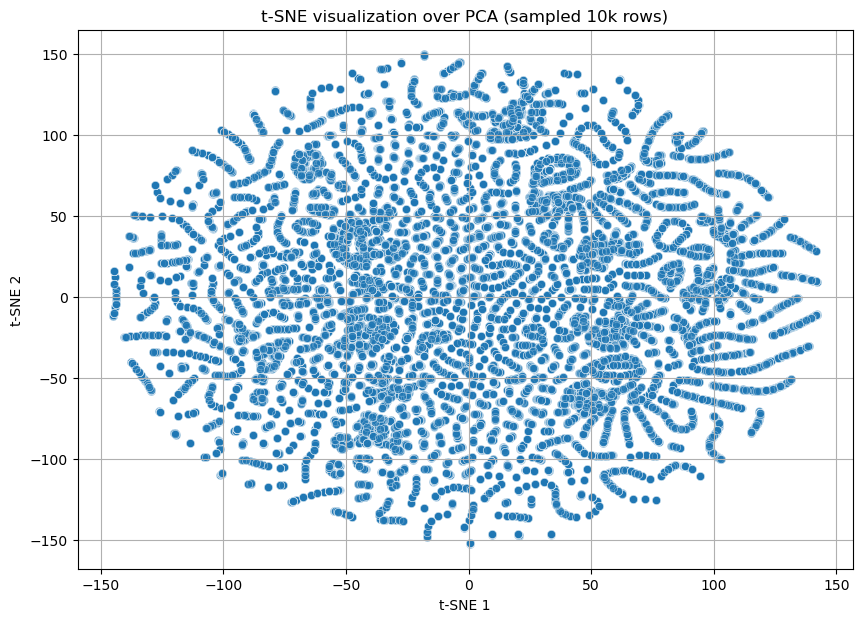

In [139]:
# Choosing a Sample since t-SNE won't be able to keep up with the full  data
X = customer_df.sample(n=60000, random_state=13) # around 10% of the data

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=13)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, perplexity=30, random_state=13)
X_tsne = tsne.fit_transform(X_pca)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], alpha=0.6)
plt.title("t-SNE visualization over PCA (sampled 10k rows)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(0.6)
plt.show()

#### Applying KMeans

##### Elbow Method

In [140]:
inertia = []
silhouette_scores = []
k_range= range(2, 25)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=13)
    
    kmeans.fit(X_pca)
    labels = kmeans.predict(X_pca)
    score= silhouette_score(X_pca, labels)
    
    silhouette_scores.append(score)
    inertia.append(kmeans.inertia_)


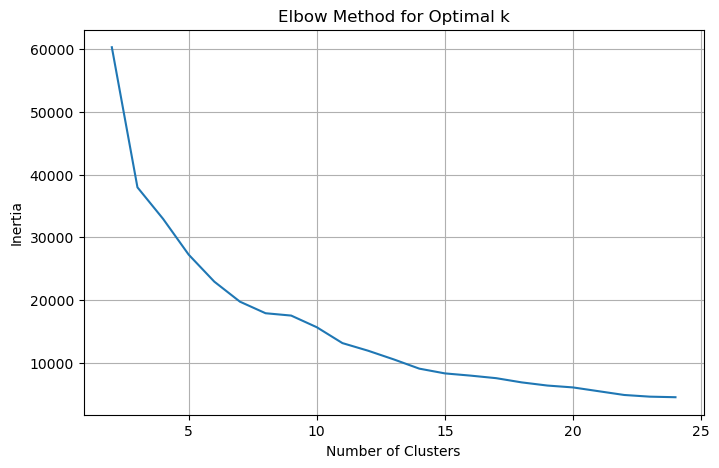

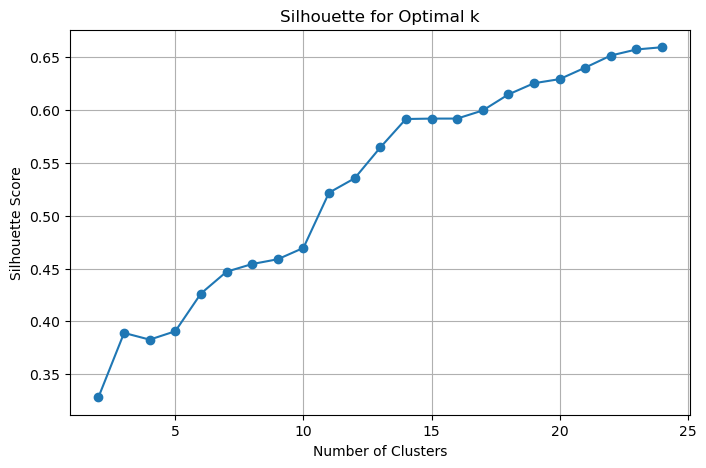

In [141]:
# Elbow Method
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(0.6)
    
    
# Silhouette Score
plt.figure(figsize=(8,5))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette for Optimal k')
plt.grid(0.6)
plt.show()

In [142]:
kmeans = KMeans(n_clusters=13, random_state=13)
clusters = kmeans.fit_predict(X_pca)

clusters

array([10,  9,  3, ...,  3,  7, 10], dtype=int32)

<Axes: >

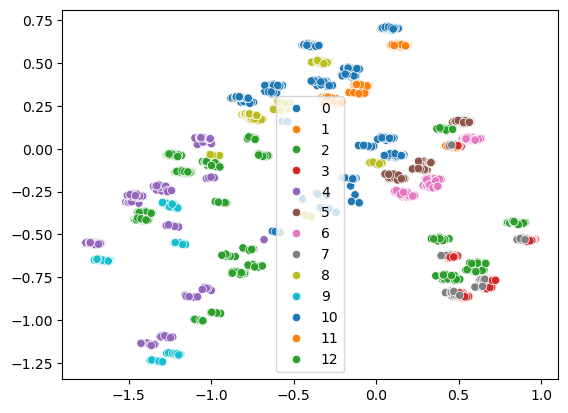

In [143]:
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='tab10')


<Axes: >

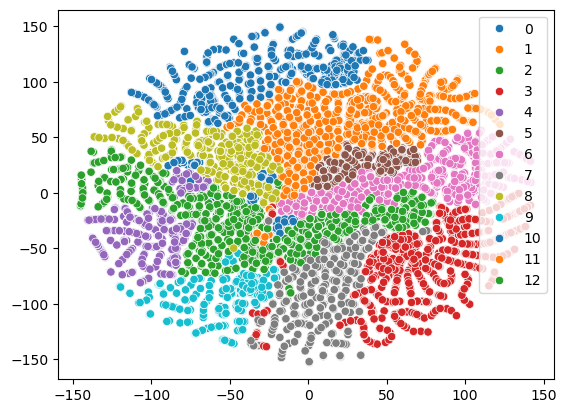

In [144]:
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=clusters, palette='tab10')

## conclusion 

After Testing using Silhoutte score and Elbow method we can say that we can cluster our data into  14 different clusters. 